In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

from sklearn.preprocessing import StandardScaler

In [3]:
from google.colab import files

uploaded = files.upload()

Saving research_dataset.csv to research_dataset.csv


In [4]:
df = pd.read_csv(
    "research_dataset.csv"
)

In [5]:
df.head()
df.columns.tolist()

['age',
 'gender',
 'daily_screen_time_hours',
 'social_media_hours',
 'gaming_hours',
 'work_study_hours',
 'sleep_hours',
 'notifications_per_day',
 'app_opens_per_day',
 'weekend_screen_time',
 'stress_level',
 'academic_work_impact',
 'addiction_level',
 'addicted_label',
 'weekend_usage_difference',
 'sleep_deficit',
 'notification_intensity',
 'weekend_overuse',
 'DEI',
 'DEI_Category',
 'attention_score',
 'attention_category',
 'addiction_level_num',
 'NDI',
 'dependency_category',
 'attention_inverse',
 'Aggression_Risk',
 'Aggression_Category']

In [6]:
#Create Wellbeing Score


df['Wellbeing_Score'] = (

    0.30 * df['attention_score']

    +

    0.25 * (
        100 - df['DEI']
    )

    +

    0.20 * (
        100 - df['NDI']
    )

    +

    0.15 * (
        100 - df['Aggression_Risk']
    )

    +

    0.10 * (
        df['sleep_hours'] * 10
    )

)

In [8]:
#Clip Score

df['Wellbeing_Score'] = (
    df['Wellbeing_Score']
    .clip(0,100)
)

In [9]:
#Create Wellbeing Categories

df['Wellbeing_Category'] = pd.cut(

    df['Wellbeing_Score'],

    bins=[0,40,70,100],

    labels=[
        'Poor',
        'Average',
        'Excellent'
    ],

    include_lowest=True

)

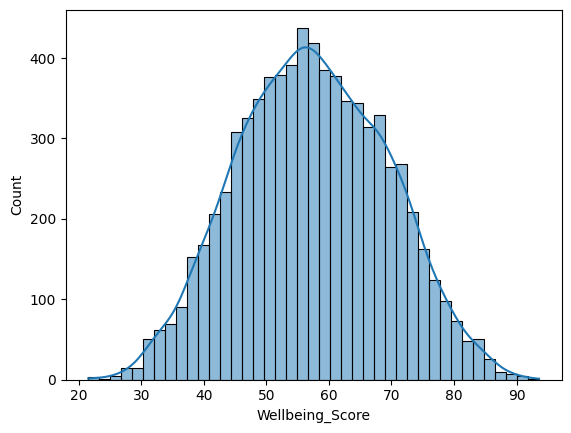

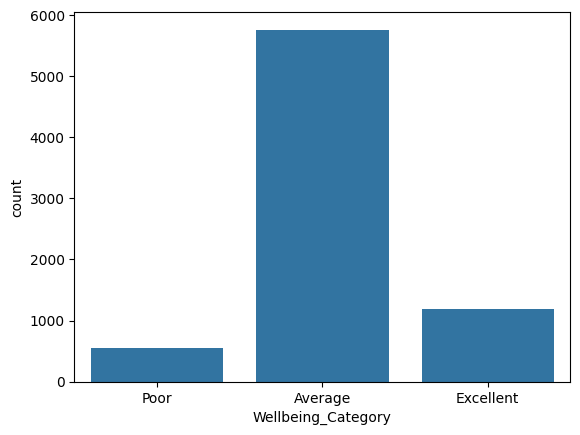

In [10]:
#Distribution

sns.histplot(
    data=df,
    x='Wellbeing_Score',
    kde=True
)

plt.show()


sns.countplot(
    data=df,
    x='Wellbeing_Category'
)

plt.show()

In [11]:
#Create User Segments

#Features:

cluster_features = [

    'DEI',

    'NDI',

    'Aggression_Risk',

    'attention_score'

]

In [12]:
#Standardize

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    df[cluster_features]
)

In [13]:
#KMeans Clustering

kmeans = KMeans(

    n_clusters=3,

    random_state=42,

    n_init=10

)

clusters = kmeans.fit_predict(
    scaled_data
)

In [15]:
#Save Cluster Labels

df['Cluster'] = clusters

#Check:

df['Cluster'].value_counts()

,count
Cluster,
0,3034
2,2233
1,2233


In [16]:
#Rename Clusters
#Find cluster means:

df.groupby(
    'Cluster'
)[

    [
        'DEI',
        'NDI',
        'Aggression_Risk',
        'attention_score'
    ]

].mean()

,DEI,NDI,Aggression_Risk,attention_score
Cluster,,,,
0,47.728846,52.281033,48.827705,67.155095
1,64.143670,62.507620,65.398528,52.047824
2,32.024105,37.813453,30.855505,81.820633


In [17]:
cluster_names = {

    0:'Healthy',

    1:'At-Risk',

    2:'High-Risk'

}

df['User_Segment'] = (
    df['Cluster']
    .map(cluster_names)
)

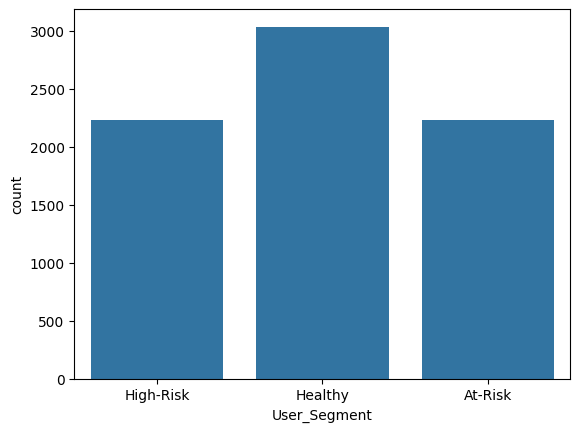

In [18]:
#Segment Distribution

sns.countplot(
    data=df,
    x='User_Segment'
)

plt.show()

In [19]:
#Create Recommendation Function

def generate_recommendation(row):

    recommendations = []

    if row['DEI'] > 66:

        recommendations.append(
            "Reduce daily screen time"
        )

    if row['NDI'] > 66:

        recommendations.append(
            "Disable non-essential notifications"
        )

    if row['sleep_hours'] < 7:

        recommendations.append(
            "Improve sleep schedule"
        )

    if row['attention_score'] < 40:

        recommendations.append(
            "Use focus sessions"
        )

    if row['Aggression_Risk'] > 66:

        recommendations.append(
            "Practice digital detox"
        )

    if len(recommendations)==0:

        recommendations.append(
            "Maintain current habits"
        )

    return "; ".join(recommendations)

In [21]:
#Generate Recommendations

df['Recommendation'] = df.apply(

    generate_recommendation,

    axis=1

)

#Check:

df[
    [

        'DEI',

        'NDI',

        'Aggression_Risk',

        'Recommendation'

    ]

].head()

,DEI,NDI,Aggression_Risk,Recommendation
0,13.434509,72.063834,33.172813,Disable non-essential notifications
1,35.196089,39.144730,33.944637,Maintain current habits
2,51.464091,28.055204,39.379843,Improve sleep schedule
3,52.636515,59.108630,55.169185,Maintain current habits
4,78.841602,78.615810,81.798630,Reduce daily screen time; Disable non-essentia...


In [22]:
#Top Recommendations
df['Recommendation'].value_counts().head(10)

,count
Recommendation,
Improve sleep schedule,2918
Maintain current habits,2537
Disable non-essential notifications,506
Disable non-essential notifications; Improve sleep schedule,339
Reduce daily screen time; Improve sleep schedule,249
Reduce daily screen time; Disable non-essential notifications; Improve sleep schedule; Practice digital detox,210
Reduce daily screen time; Improve sleep schedule; Practice digital detox,205
Disable non-essential notifications; Improve sleep schedule; Practice digital detox,195
Disable non-essential notifications; Practice digital detox,128


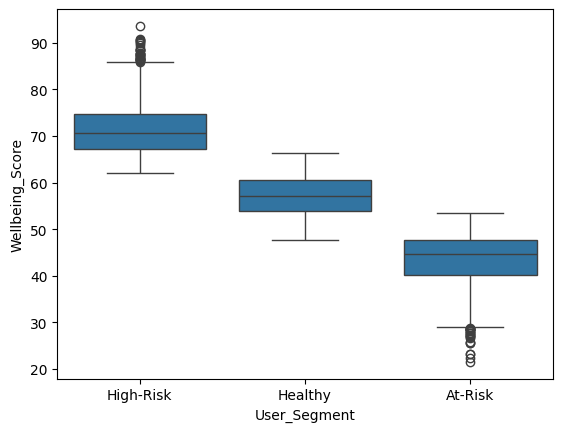

In [23]:
#Segment vs Wellbeing

sns.boxplot(

    data=df,

    x='User_Segment',

    y='Wellbeing_Score'

)

plt.show()

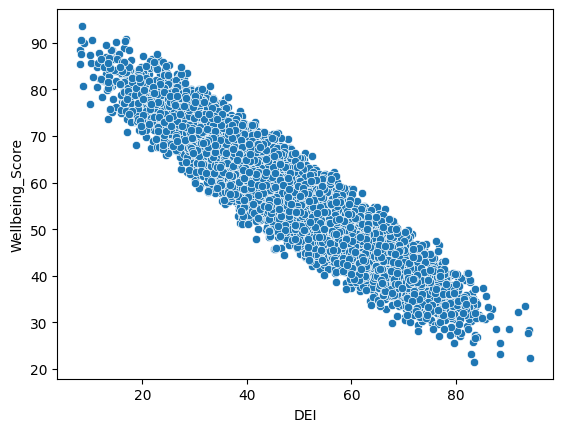

In [24]:
#DEI vs Wellbeing

sns.scatterplot(

    data=df,

    x='DEI',

    y='Wellbeing_Score'

)

plt.show()

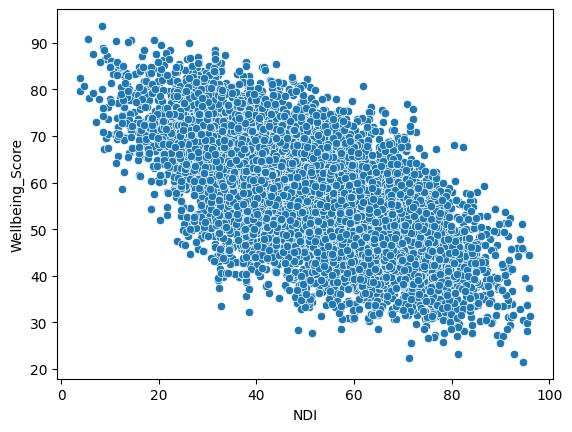

In [25]:
#NDI vs Wellbeing

sns.scatterplot(

    data=df,

    x='NDI',

    y='Wellbeing_Score'

)

plt.show()

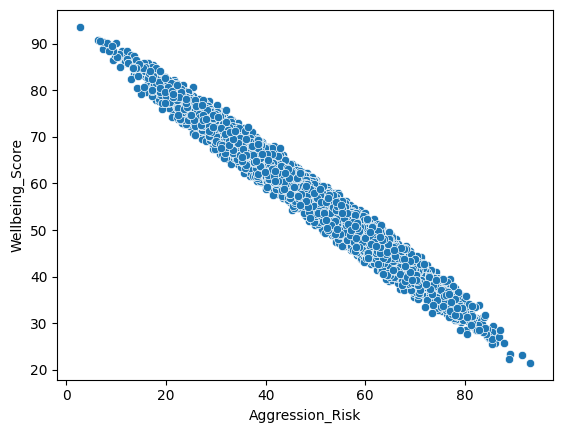

In [26]:
#Aggression vs Wellbeing

sns.scatterplot(

    data=df,

    x='Aggression_Risk',

    y='Wellbeing_Score'

)

plt.show()

In [27]:
df.to_csv(

    "dashboard_dataset.csv",

    index=False

)

In [28]:
from google.colab import files

files.download(
    "dashboard_dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Research Findings

1. Users with higher DEI show lower wellbeing scores.

2. High notification dependency is associated with lower wellbeing.

3. Sleep contributes positively to overall wellbeing.

4. High-risk users require intervention strategies.

5. Personalized recommendations can be generated using behavioral indicators.